In [1]:
import cv2 as cv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import glob
import numpy as np

from labelme import utils
from labelme._label_file import LabelFile

# find json annotation files
target_path = Path("TestwithMapping/")
target_jsons = []
for target in target_path.iterdir():
    if target.stem.isnumeric():
        annotations = target.glob("*.json")
        for annot in annotations:
            target_jsons.append(annot)

# copy initial images and export segmentation masks by region
output_dir = Path(r"dataset_split")

print(f"Found {len(target_jsons)} .json files. Starting conversion...")
for json_file in target_jsons:
    label_file = LabelFile(filename=json_file)
    parent = json_file.parent
    base = parent.name
    initial_img = cv.imread(parent / f'Initial-{base}.png')

    for s in label_file.shapes:
        region = s['label']
        label_name_to_value = {"_background_": 0, region: 1}
        
        lbl, _ = utils.shapes_to_label(
            initial_img.shape, [s], label_name_to_value
        )
    
        img_out_path = output_dir / region / "images" / f"{base}.png"
        mask_out_path = output_dir / region / "SegmentationClass" / f"{base}.png"
        img_out_path.parent.mkdir(parents=True, exist_ok=True)
        mask_out_path.parent.mkdir(parents=True, exist_ok=True)

        cv.imwrite(img_out_path, initial_img)
        utils.lblsave(mask_out_path, lbl)

Found 39 .json files. Starting conversion...


In [1]:
# reimport when restarting kernel

import cv2 as cv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import glob
import numpy as np

# train individual model

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Sampler
import copy
import ttach as tta
from torch.utils.data import Subset
from tqdm import tqdm
import sys

class RandomRepeatSampler(Sampler):
    """
    Samples elements randomly, with replacement, to reach a desired epoch length.
    
    Arguments:
        data_source (Dataset): dataset to sample from
        epoch_length (int): The number of samples to draw per epoch
    """
    def __init__(self, data_source, epoch_length):
        self.data_source = data_source
        self.epoch_length = epoch_length

    def __iter__(self):
        # Generate a list of random indices (with replacement)
        indices = torch.randint(high=len(self.data_source), 
                                size=(self.epoch_length,), 
                                dtype=torch.int64)
        return iter(indices.tolist())

    def __len__(self):
        return self.epoch_length

class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.dice_loss = smp.losses.DiceLoss(mode='binary')
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, outputs, targets):
        dice_loss = self.dice_loss(outputs, targets)
        bce_loss = self.bce_loss(outputs, targets)
        
        # Combine the losses
        combined_loss = (self.dice_weight * dice_loss) + (self.bce_weight * bce_loss)
        return combined_loss

# Define transforms for training (with augmentation)
train_transform = A.Compose([
    A.Resize(1024, 1024),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    #A.RandomRotate90(p=0.8),
    A.Rotate(limit=360, p=0.7, border_mode=cv.BORDER_CONSTANT),
    #A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, p=0.5, border_mode=cv.BORDER_CONSTANT, value=0),
    A.ElasticTransform(p=0.5, border_mode=cv.BORDER_CONSTANT),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # ImageNet stats
    ToTensorV2(),
])

# Define transforms for validation (no augmentation)
val_transform = A.Compose([
    A.Resize(1024, 1024),
    #A.PadIfNeeded(min_height=None, min_width=None, pad_height_divisor=32, pad_width_divisor=32),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class BrainDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.images = sorted(self.image_dir.glob("*.png"))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx].name
        img_path = self.images[idx]
        mask_path = self.mask_dir / img_name # Assumes mask name matches image name

        image = cv.imread(img_path)
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        mask = cv.imread(mask_path, cv.IMREAD_GRAYSCALE)
        
        mask[mask > 0] = 1.0 # Normalize mask to 0.0 or 1.0

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Add channel dim to mask: (H, W) -> (1, H, W)
        mask = mask.unsqueeze(0).float()

        return image, mask

def train_model(model, train_loader, val_loader, loss_fn, optimizer, scheduler, num_epochs=25, name="best_model"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    best_val_loss = float('inf')
    #tta_transforms = tta.aliases.d4_transform()
    accumulation_steps = 8

    for epoch in range(num_epochs):
        model.train() # Training mode
        train_loss = 0.0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", file=sys.stdout)
        optimizer.zero_grad()
        
        for i, (images, masks) in enumerate(loop):
            images = images.to(device)
            masks = masks.to(device)
            
            # forward Pass
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            
            # normalize loss (average it over the accumulation steps)
            loss = loss / accumulation_steps 
            
            # backward Pass (Accumulate gradients)
            loss.backward()
            
            # update Weights ONLY every 'accumulation_steps'
            if (i + 1) % accumulation_steps == 0:
                optimizer.step()
                optimizer.zero_grad()
            
            # Multiply by accumulation_steps to log the 'real' loss value for display
            train_loss += (loss.item() * accumulation_steps) * images.size(0)
            
            loop.set_postfix(loss=loss.item() * accumulation_steps)
            
        # Handle any remaining gradients if the dataset size isn't divisible by accumulation_steps
        if (i + 1) % accumulation_steps != 0:
             optimizer.step()
             optimizer.zero_grad()
        
        # Validation
        model.eval() # Evaluation mode
        
        #tta_model = tta.SegmentationTTAWrapper(model, tta_transforms, merge_mode='mean') # test-time augmentation
        #tta_model.to(device)
        
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)
                
                #outputs = tta_model(images)
                outputs = model(images)
                loss = loss_fn(outputs, masks)
                val_loss += loss.item() * images.size(0)

        avg_train_loss = train_loss / len(train_loader.sampler)
        avg_val_loss = val_loss / len(val_loader.dataset)

        scheduler.step(avg_val_loss)
        
        loop.write(f"Epoch {epoch+1}/{num_epochs} \t Train Loss: {avg_train_loss:.6f} \t Val Loss: {avg_val_loss:.6f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f'{name}.pth')
            loop.write(f"Model saved as {name}.pth")

    print("Training complete.")

def run(region):
    output_dir = Path(r"dataset_split")
    image_dir = output_dir / region / "images"
    mask_dir = output_dir / region / "SegmentationClass"
    
    learning_rate = 0.001
    batch_size = 2
    num_epochs = 50 
    
    full_dataset = BrainDataset(image_dir, mask_dir, transform=train_transform)
    
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    #train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    with open(f"region1_validation_indices.txt", "r", encoding="utf-8") as f: # load previous training split
        lines = f.read().strip().split("\n")
        validation_indices = np.array(lines).astype(int)
    
    with open(f"region1_train_indices.txt", "r", encoding="utf-8") as f:
        lines = f.read().strip().split("\n")
        train_indices = np.array(lines).astype(int)
    
    train_dataset = Subset(full_dataset, train_indices)
    val_dataset = Subset(full_dataset, validation_indices)
    
    val_dataset.dataset = copy.deepcopy(val_dataset.dataset)
    val_dataset.dataset.transform = val_transform
    
    with open(f"{region}_validation_paths.txt", "w", encoding="utf-8") as f:
        f.write(str(full_dataset.mask_dir) + "\n")
        for line in np.array(full_dataset.images)[val_dataset.indices].astype(str):
            f.write(line+"\n")
    
    train_epoch_length= 500
    train_sampler = RandomRepeatSampler(train_dataset, train_epoch_length)
    train_loader = DataLoader(train_dataset, sampler=train_sampler, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
    
    model = smp.Unet(
        encoder_name="efficientnet-b0",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    )
    
    loss_fn = CombinedLoss(dice_weight=0.5, bce_weight=0.5)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)
    
    train_model(model, train_loader, val_loader, loss_fn, optimizer, scheduler, num_epochs=num_epochs, name=f"{region}_model")

run("region1")
run("region2")

C:\Users\Nolan\anaconda3\envs\sandia_new\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50: 100%|████████████████████████████████████████████████████████| 250/250 [02:32<00:00,  1.64it/s, loss=0.351]
Epoch 1/50 	 Train Loss: 0.438875 	 Val Loss: 0.312172
Model saved as region1_model.pth
Epoch 2/50: 100%|████████████████████████████████████████████████████████| 250/250 [02:40<00:00,  1.56it/s, loss=0.202]
Epoch 2/50 	 Train Loss: 0.258622 	 Val Loss: 0.338737
Epoch 3/50: 100%|████████████████████████████████████████████████████████| 250/250 [02:49<00:00,  1.48it/s, loss=0.198]
Epoch 3/50 	 Train Loss: 0.229056 	 Val Loss: 0.282403
Model saved as region1_model.pth
Epoch 4/50: 100%|████████████████████████████████████████████████████████| 250/250 [02:33<00:00,  1.63it/s, loss=0.131]
Epoch 4/50 	 Train Loss: 0.215688 	 Val Loss: 0.260892
Model saved as region1_model.pth
Epoch 5/50: 100%|█████████████████████████████████████████████████████████| 250/250 [02:41<00:00,  1.55it/s, loss=0.13]
Epoch 5/50 	 Train Loss: 0.185225 	 Val Loss: 0.267828
Epoch 6/50: 100%|█████████

In [2]:
# check validation set

with open("region1_validation_paths.txt", "r", encoding="utf-8") as f:
    lines = f.read().strip().split("\n")
    segmentation_dir1 = Path(lines[0]).parent.parent / "Region1" / "SegmentationClass"
    validation_images1 = [Path(d) for d in lines[1:]]
    segmentation_images1 = [segmentation_dir1 / vd.name for vd in validation_images1]
    names1 = [vd.name for vd in validation_images1]

with open("region2_validation_paths.txt", "r", encoding="utf-8") as f:
    lines = f.read().strip().split("\n")
    segmentation_dir2 = Path(lines[0])
    validation_images2 = [Path(d) for d in lines[1:]]
    segmentation_images2 = [segmentation_dir2 / vd.name for vd in validation_images2]
    names2 = [vd.name for vd in validation_images2]

assert len(names1) == len(names2) == len([name for name in names1 if name in names2]), "Both models must share training split!"

In [ ]:
def calculate_dice_score(pred_mask, true_mask):
    pred_mask = (pred_mask > 0).astype(np.uint8)
    true_mask = (true_mask > 0).astype(np.uint8)
    intersection = np.sum(pred_mask * true_mask)
    total_pred = np.sum(pred_mask)
    total_true = np.sum(true_mask)
    epsilon = 1e-6

    dice = (2. * intersection + epsilon) / (total_pred + total_true + epsilon)
    return dice

def run_model(model_path, image_tensor):
    model = smp.Unet(
        encoder_name="efficientnet-b0",
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation=None
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
    model.to(device)
    model.eval()
    
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        logits = model(image_tensor)
        probs = torch.sigmoid(logits)
        mask = (probs > 0.5).float().cpu().numpy().squeeze()
    
    return mask

dices=[]
for target in range(len(names1)):
    evaluation_image = cv.cvtColor(cv.imread(validation_images1[target]), cv.COLOR_BGR2RGB)
    eval_augmented = val_transform(image=evaluation_image)
    image_tensor = eval_augmented['image'].unsqueeze(0)

    h, w = evaluation_image.shape[:2]
    region1_mask = run_model(r"gradient accumulation/region1_model.pth", image_tensor)
    r1_resized = cv.resize(region1_mask, (w, h), interpolation=cv.INTER_NEAREST)
    overlay_r1 = np.zeros_like(evaluation_image, dtype=np.uint8)
    overlay_r1[r1_resized == 1] = (255, 0, 0)
    
    region2_mask = run_model(r"gradient accumulation/region2_model.pth", image_tensor)
    r2_resized = cv.resize(region2_mask, (w, h), interpolation=cv.INTER_NEAREST)
    overlay_r2 = np.zeros_like(evaluation_image, dtype=np.uint8)
    overlay_r2[r2_resized == 1] = (0, 255, 0)

    combined = np.zeros((h, w), dtype=evaluation_image.dtype)
    combined[r1_resized == 1] = 255
    combined[r2_resized == 1] = 255

    combined_rgb = np.zeros_like(evaluation_image, dtype=np.uint8)
    r1_r = np.zeros_like(evaluation_image, dtype=np.uint8)
    r2_g = np.zeros_like(evaluation_image, dtype=np.uint8)
    combined_rgb[r1_resized == 1] = (255, 0, 0)
    r1_r[r1_resized == 1] = (255, 0, 0)
    combined_rgb[r2_resized == 1] = (0, 255, 0)
    r2_g[r2_resized == 1] = (0, 255, 0)
    
    fig, axes = plt.subplots(1, 3, figsize=(5, 3))

    combined_overlay = cv.addWeighted(evaluation_image, 1, overlay_r1, 0.4, 0)
    combined_overlay = cv.addWeighted(combined_overlay, 1, overlay_r2, 0.4, 0)
    axes[0].imshow(combined_overlay)
    axes[0].set_title(f"Model Results")
    axes[0].axis("off")

    original_mask_1 = cv.cvtColor(cv.imread(segmentation_images1[target]), cv.COLOR_BGR2RGB)
    original_mask_2 = cv.cvtColor(cv.imread(segmentation_images2[target]), cv.COLOR_BGR2RGB)
    original_mask = np.zeros_like(original_mask_1, dtype=np.uint8)
    original_mask[cv.cvtColor(original_mask_1, cv.COLOR_BGR2GRAY) != 0] = (255, 0, 0)
    original_mask[cv.cvtColor(original_mask_2, cv.COLOR_BGR2GRAY) != 0] = (0, 255, 0)
    #original_mask = cv.rotate(original_mask, cv.ROTATE_90_CLOCKWISE)
    axes[1].imshow(original_mask)
    axes[1].set_title(f"Original Mask")
    axes[1].axis("off")

    axes[2].imshow(combined_rgb)
    axes[2].set_title(f"Model Mask")
    axes[2].axis("off")

    plt.suptitle(f'Results for {names1[target]}')
    dice_score = calculate_dice_score(combined, cv.cvtColor(original_mask, cv.COLOR_RGB2GRAY))
    dices.append(dice_score)
    fig.text(0.5, 0.02, f'Overlap: {dice_score*100:.2f}%', ha='center', fontsize=12)
    plt.tight_layout()
    # plt.savefig(f'{names1[target].split(".")[0]}_result.png', dpi=400)
    save_dir = Path(f'gradient accumulation/{names1[target].split(".")[0]}_result')
    save_dir.mkdir(exist_ok=True)
    # cv.imwrite(save_dir / f'{names1[target].split(".")[0]}_validation.png', cv.cvtColor(evaluation_image, cv.COLOR_RGB2BGR))
    # cv.imwrite(save_dir / f'{names1[target].split(".")[0]}_original.png', cv.cvtColor(original_mask, cv.COLOR_RGB2BGR))
    # cv.imwrite(save_dir / f'{names1[target].split(".")[0]}_model_combined.png', cv.cvtColor(combined_rgb, cv.COLOR_RGB2BGR))
    # cv.imwrite(save_dir / f'{names1[target].split(".")[0]}_model_region1.png', cv.cvtColor(r1_r, cv.COLOR_RGB2BGR))
    # cv.imwrite(save_dir / f'{names1[target].split(".")[0]}_model_region2.png', cv.cvtColor(r2_g, cv.COLOR_RGB2BGR))
    plt.show()

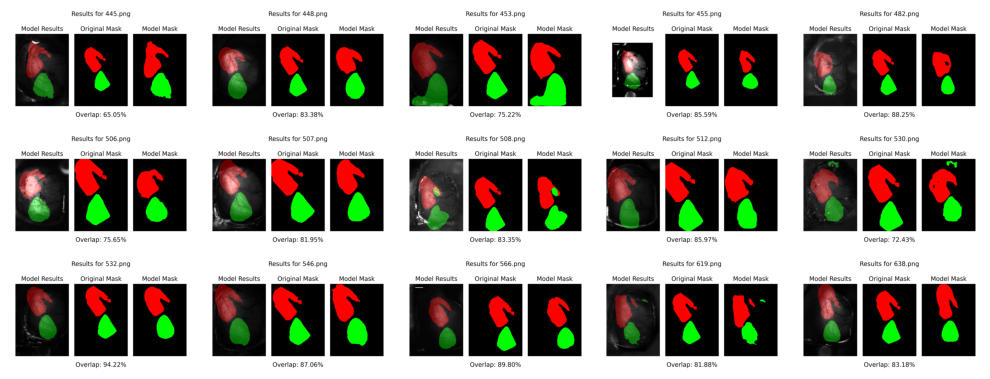

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

grid_folder = r"C:\Users\Nolan\Documents\Python Scripts\ECE 549\final\gradient accumulation"
images = list(Path(grid_folder).glob("*png"))

rows = 3
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(10, 4))

current_img = 0
for r in range(rows):
    for c in range(cols):
        axes[r, c].axis('off')
        if current_img < len(images):
            img = mpimg.imread(images[current_img])
            axes[r, c].imshow(img)
            current_img += 1

plt.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout()
plt.savefig('grid.png', dpi=400, bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
print(f'x̄ = {np.mean(dices):.2f}%, σ = {np.std(dices):.0f}%')